In [1]:
STEP = 4
LEARNING_RATE = 1e-3 * 0.5 ** (STEP - 1)
BATCH_SIZE = 8
EPOCHS = 200
MAX_PATIENCE = 50 if STEP > 2 else 80
MIN_PATIENCE = MAX_PATIENCE // 2
print(f"Learning rate: {LEARNING_RATE}, Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

Learning rate: 0.000125, Batch size: 8, Epochs: 200


In [2]:
from models.dataset import ImageDataset
from torch.utils.data import DataLoader
train_dataset = ImageDataset(hr_root=r"Data/DIV2K_train_HR", lr_root=r"Data/DIV2K_train_LR_bicubic/X4", lr_suffix="x4", ratio=4)
test_dataset = ImageDataset(hr_root=r"Data/valid_HR", lr_root=r"Data/valid_LR", lr_suffix="", ratio=4, train=False)
final_test_dataset = ImageDataset(hr_root=r"Data/DIV2K_valid_HR", lr_root=r"Data/DIV2K_valid_LR_bicubic/X4", lr_suffix="x4", ratio=4, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)
final_test_loader = DataLoader(final_test_dataset, batch_size=1, shuffle=False, num_workers=8, pin_memory=True)

In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
import os
from models.dlgsanet import DLGSANet
import torch.nn as nn
model = DLGSANet()
model_weights = f"weights/dlgsanet_{STEP:02d}.pth"
autocast = torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=True)
if os.path.exists(model_weights):
    model.load_state_dict(torch.load(model_weights, map_location=device))
elif STEP > 1:
    model_weights = f"weights/dlgsanet_{STEP-1:02d}.pth"
    if os.path.exists(model_weights):
        model.load_state_dict(torch.load(model_weights, map_location=device))
model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
num_params = count_parameters(model)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 2534496


In [5]:
from tqdm import tqdm
best_loss = float("inf")
# Initial validation
model.eval()
running_test_loss = 0.0
with torch.inference_mode():
    for lr_images, hr_images in tqdm(test_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        with autocast:
            outputs = model(lr_images)
            loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
test_loss = running_test_loss / len(test_loader)

if test_loss < best_loss:
    best_loss = test_loss
    #torch.save(model.state_dict(), model_weights)
print(f"Initial Best Loss: {best_loss:.9f}")

100%|██████████| 200/200 [01:59<00:00,  1.67it/s]

Initial Best Loss: 0.025171713


100%|██████████| 200/200 [02:05<00:00,  1.59it/s]


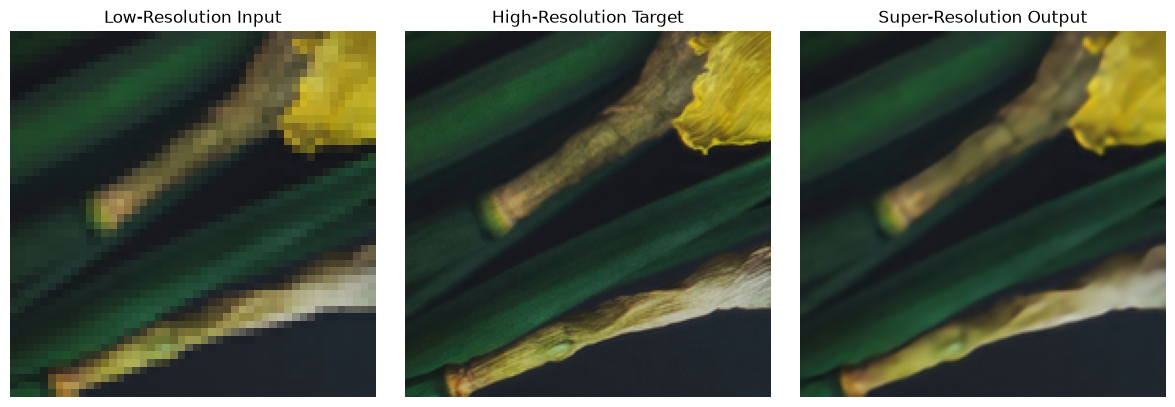

Epoch [1/200] Train Loss: 0.025852369 Val Loss: 0.025013814 Best: 0.025013814
Training time: 163.06s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


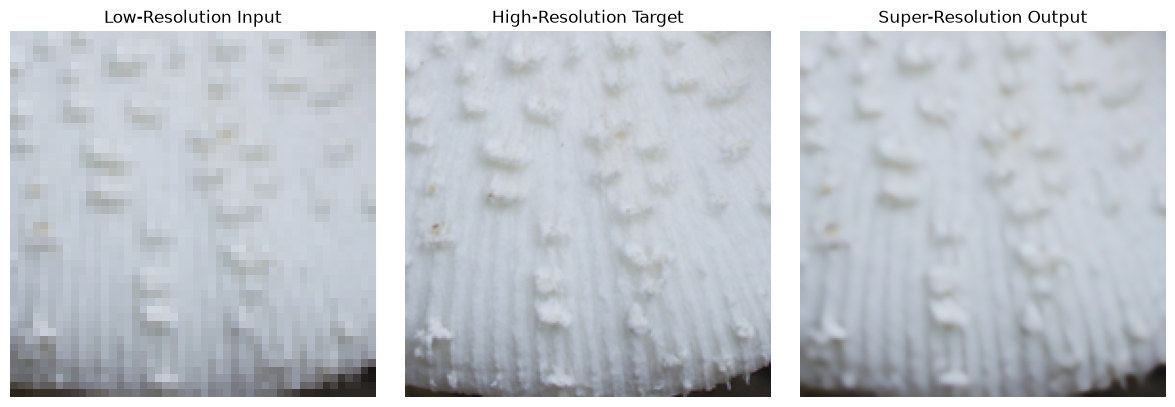

Epoch [2/200] Train Loss: 0.026047934 Val Loss: 0.024964109 Best: 0.024964109
Training time: 325.57s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [3/200] Train Loss: 0.024780774 Val Loss: 0.025079328 Best: 0.024964109
Training time: 487.94s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [4/200] Train Loss: 0.026323167 Val Loss: 0.025049993 Best: 0.024964109
Training time: 650.15s


100%|██████████| 200/200 [02:07<00:00,  1.56it/s]


Epoch [5/200] Train Loss: 0.026409589 Val Loss: 0.024976503 Best: 0.024964109
Training time: 812.91s


100%|██████████| 200/200 [02:08<00:00,  1.56it/s]


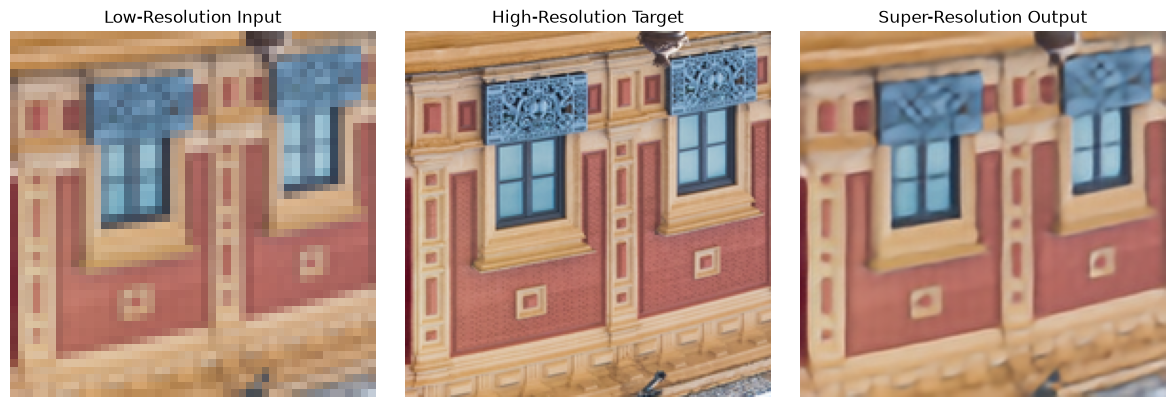

Epoch [6/200] Train Loss: 0.025425845 Val Loss: 0.024890880 Best: 0.024890880
Training time: 976.06s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [7/200] Train Loss: 0.026524237 Val Loss: 0.024913889 Best: 0.024890880
Training time: 1138.23s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [8/200] Train Loss: 0.026101498 Val Loss: 0.024965542 Best: 0.024890880
Training time: 1299.94s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [13/200] Train Loss: 0.026044462 Val Loss: 0.024997229 Best: 0.024890880
Training time: 2108.38s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [14/200] Train Loss: 0.025456452 Val Loss: 0.025143833 Best: 0.024890880
Training time: 2270.24s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


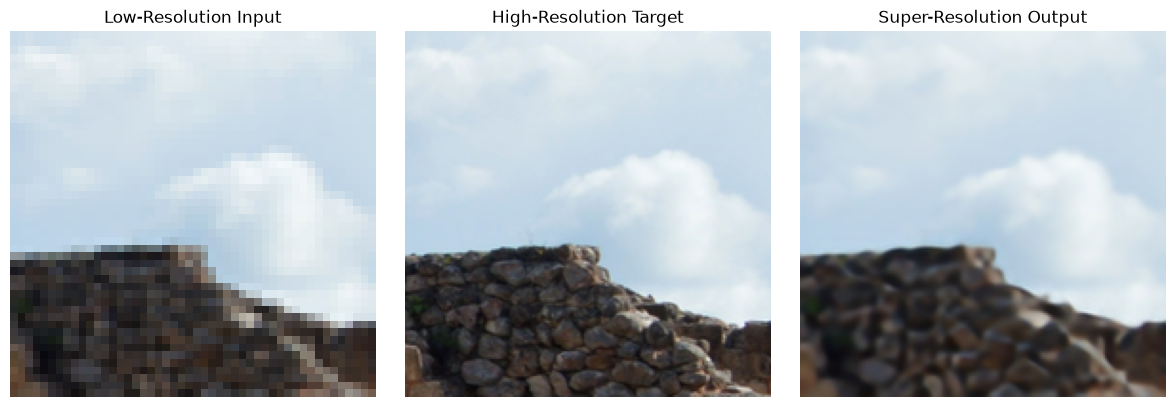

Epoch [15/200] Train Loss: 0.025993162 Val Loss: 0.024873840 Best: 0.024873840
Training time: 2432.40s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [16/200] Train Loss: 0.026501732 Val Loss: 0.025060051 Best: 0.024873840
Training time: 2594.29s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [17/200] Train Loss: 0.024328739 Val Loss: 0.024896725 Best: 0.024873840
Training time: 2756.45s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [18/200] Train Loss: 0.026223062 Val Loss: 0.024926790 Best: 0.024873840
Training time: 2918.27s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


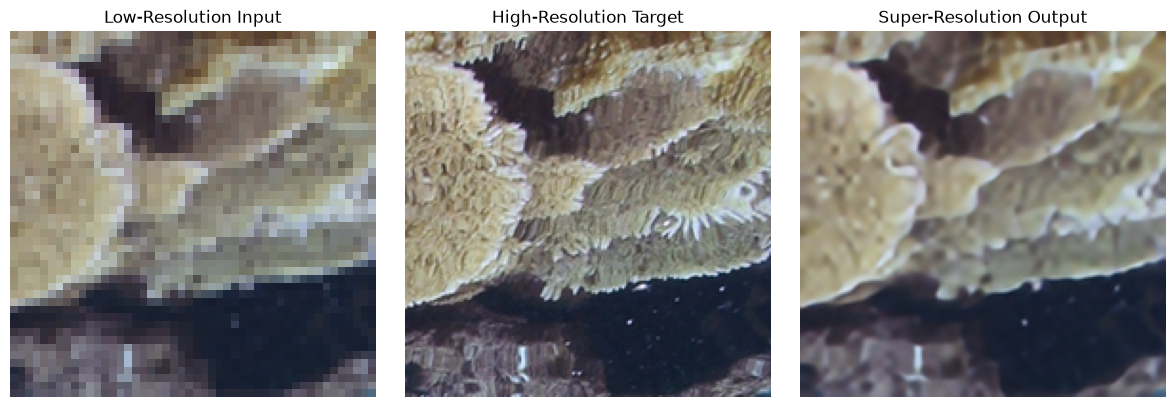

Epoch [19/200] Train Loss: 0.025920600 Val Loss: 0.024867740 Best: 0.024867740
Training time: 3079.89s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [20/200] Train Loss: 0.025026614 Val Loss: 0.024933212 Best: 0.024867740
Training time: 3241.62s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [21/200] Train Loss: 0.026242274 Val Loss: 0.025050800 Best: 0.024867740
Training time: 3402.89s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [22/200] Train Loss: 0.025469518 Val Loss: 0.024999498 Best: 0.024867740
Training time: 3564.18s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


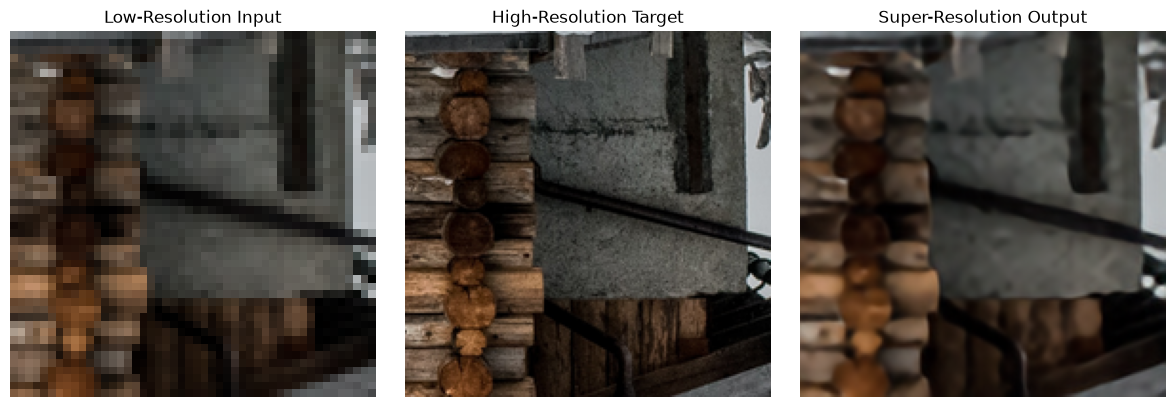

Epoch [23/200] Train Loss: 0.026074590 Val Loss: 0.024802599 Best: 0.024802599
Training time: 3726.21s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [24/200] Train Loss: 0.025051136 Val Loss: 0.025057436 Best: 0.024802599
Training time: 3887.61s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [25/200] Train Loss: 0.025025027 Val Loss: 0.024900479 Best: 0.024802599
Training time: 4049.29s


...

100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [29/200] Train Loss: 0.025843194 Val Loss: 0.025081589 Best: 0.024802599
Training time: 4695.69s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [30/200] Train Loss: 0.025338949 Val Loss: 0.024911817 Best: 0.024802599
Training time: 4856.72s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


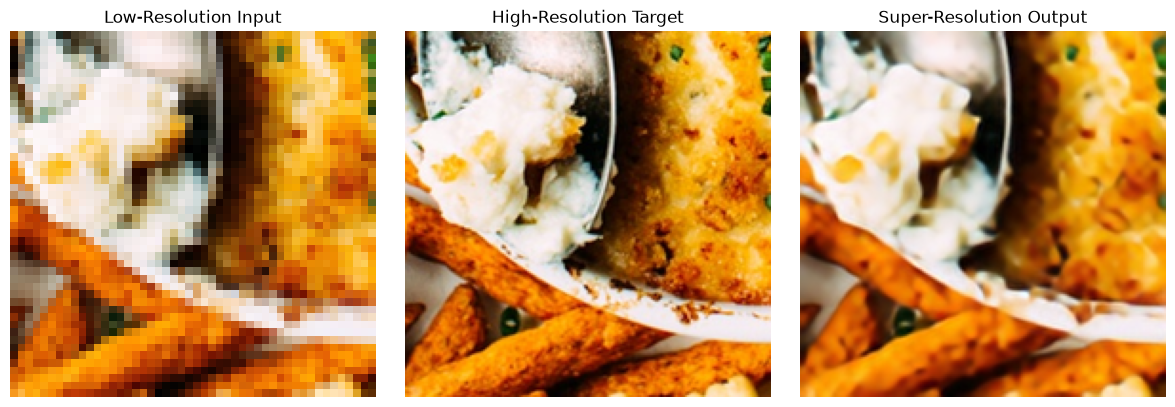

Epoch [31/200] Train Loss: 0.025651969 Val Loss: 0.024790580 Best: 0.024790580
Training time: 5018.50s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [32/200] Train Loss: 0.025343123 Val Loss: 0.024903802 Best: 0.024790580
Training time: 5180.08s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [33/200] Train Loss: 0.025185265 Val Loss: 0.024992890 Best: 0.024790580
Training time: 5341.34s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [38/200] Train Loss: 0.026940723 Val Loss: 0.024931297 Best: 0.024790580
Training time: 6150.31s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [39/200] Train Loss: 0.025727477 Val Loss: 0.024898503 Best: 0.024790580
Training time: 6311.81s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


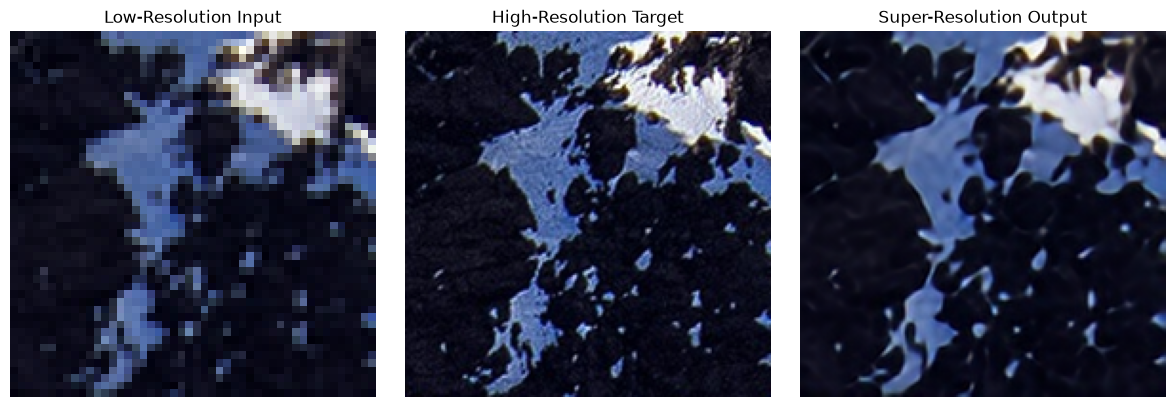

Epoch [40/200] Train Loss: 0.025495685 Val Loss: 0.024779979 Best: 0.024779979
Training time: 6473.69s


100%|██████████| 200/200 [02:06<00:00,  1.57it/s]


Epoch [41/200] Train Loss: 0.026599627 Val Loss: 0.024957768 Best: 0.024779979
Training time: 6635.10s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [42/200] Train Loss: 0.026205197 Val Loss: 0.024885055 Best: 0.024779979
Training time: 6796.71s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [55/200] Train Loss: 0.025741434 Val Loss: 0.024827431 Best: 0.024779979
Training time: 8897.25s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [56/200] Train Loss: 0.025034280 Val Loss: 0.024881420 Best: 0.024779979
Training time: 9059.59s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


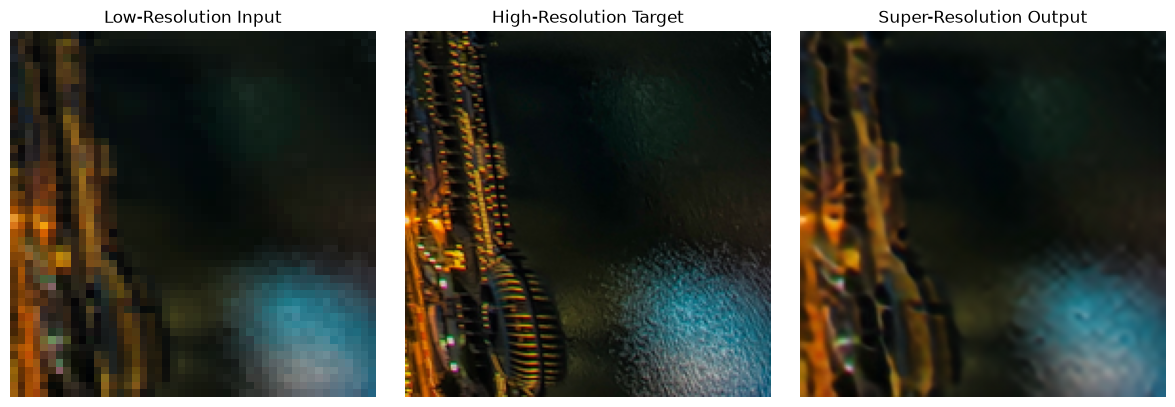

Epoch [57/200] Train Loss: 0.023847866 Val Loss: 0.024747476 Best: 0.024747476
Training time: 9221.79s


100%|██████████| 200/200 [02:09<00:00,  1.55it/s]


Epoch [58/200] Train Loss: 0.024851177 Val Loss: 0.024870583 Best: 0.024747476
Training time: 9385.61s


100%|██████████| 200/200 [02:10<00:00,  1.53it/s]


Epoch [59/200] Train Loss: 0.025301965 Val Loss: 0.024899316 Best: 0.024747476
Training time: 9551.43s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [66/200] Train Loss: 0.025134844 Val Loss: 0.024863487 Best: 0.024747476
Training time: 10680.82s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [67/200] Train Loss: 0.026237585 Val Loss: 0.024808042 Best: 0.024747476
Training time: 10842.18s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


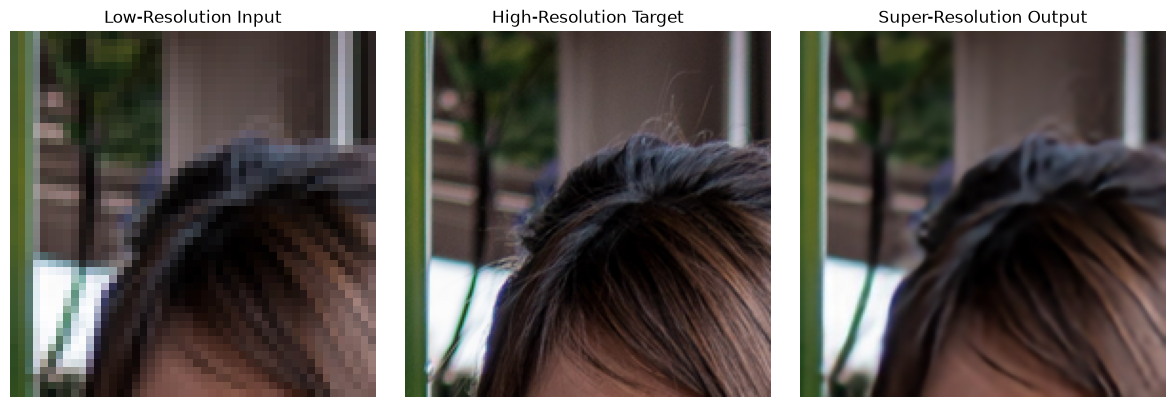

Epoch [68/200] Train Loss: 0.026738157 Val Loss: 0.024738556 Best: 0.024738556
Training time: 11003.87s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [69/200] Train Loss: 0.025108285 Val Loss: 0.024817224 Best: 0.024738556
Training time: 11165.78s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [70/200] Train Loss: 0.025226243 Val Loss: 0.024744448 Best: 0.024738556
Training time: 11327.08s


...

100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [79/200] Train Loss: 0.026220903 Val Loss: 0.024868443 Best: 0.024738556
Training time: 12779.94s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [80/200] Train Loss: 0.025870676 Val Loss: 0.024744517 Best: 0.024738556
Training time: 12941.56s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


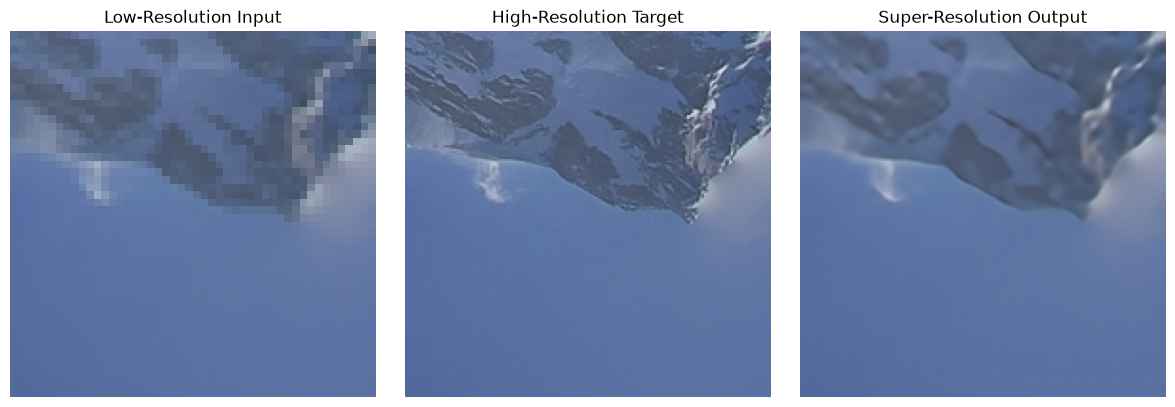

Epoch [81/200] Train Loss: 0.025303983 Val Loss: 0.024734174 Best: 0.024734174
Training time: 13103.82s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [82/200] Train Loss: 0.026539019 Val Loss: 0.024801718 Best: 0.024734174
Training time: 13264.98s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


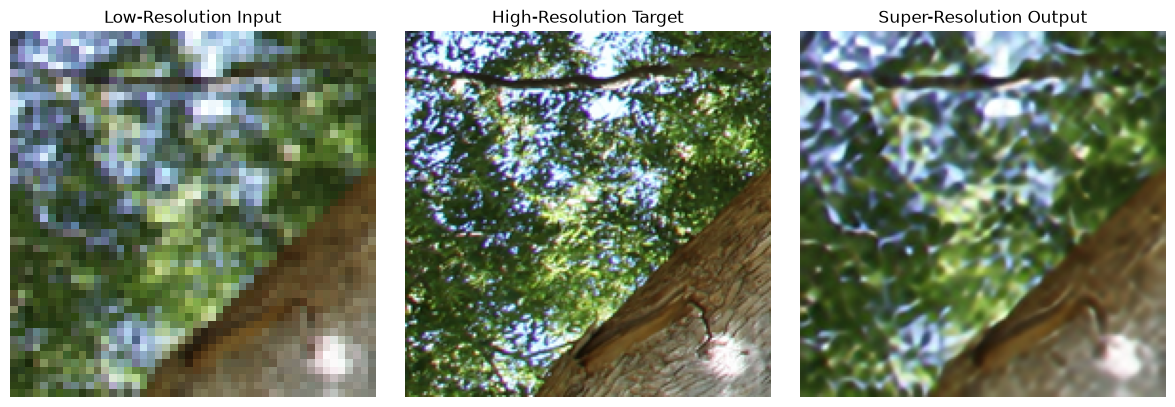

Epoch [83/200] Train Loss: 0.026232573 Val Loss: 0.024728639 Best: 0.024728639
Training time: 13426.64s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [84/200] Train Loss: 0.025050578 Val Loss: 0.024765985 Best: 0.024728639
Training time: 13588.43s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [85/200] Train Loss: 0.025212979 Val Loss: 0.024749126 Best: 0.024728639
Training time: 13749.92s


...

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [87/200] Train Loss: 0.026045455 Val Loss: 0.024866717 Best: 0.024728639
Training time: 14072.90s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [88/200] Train Loss: 0.025367381 Val Loss: 0.024822279 Best: 0.024728639
Training time: 14234.61s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


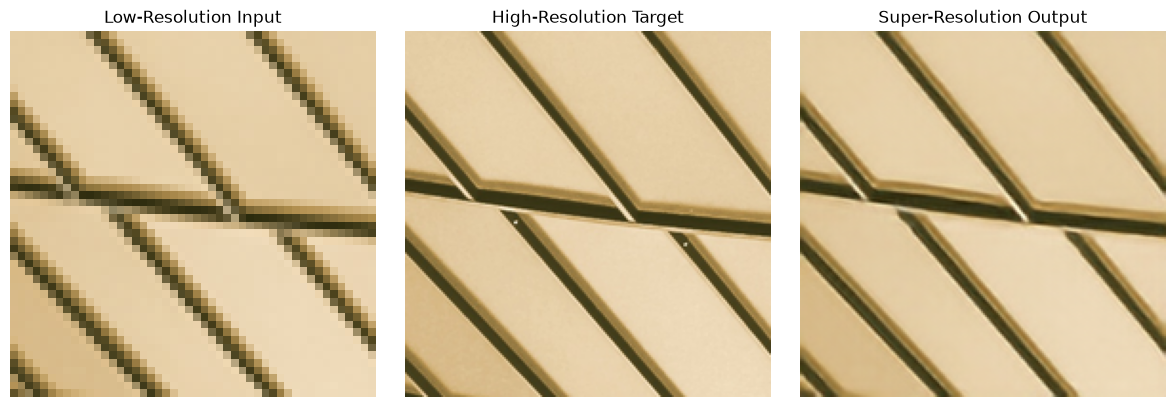

Epoch [89/200] Train Loss: 0.025747802 Val Loss: 0.024694937 Best: 0.024694937
Training time: 14396.23s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [90/200] Train Loss: 0.025294977 Val Loss: 0.024778100 Best: 0.024694937
Training time: 14557.93s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [91/200] Train Loss: 0.026769207 Val Loss: 0.024756651 Best: 0.024694937
Training time: 14719.44s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [92/200] Train Loss: 0.024892687 Val Loss: 0.024735869 Best: 0.024694937
Training time: 14880.61s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [93/200] Train Loss: 0.025215770 Val Loss: 0.024819811 Best: 0.024694937
Training time: 15042.25s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


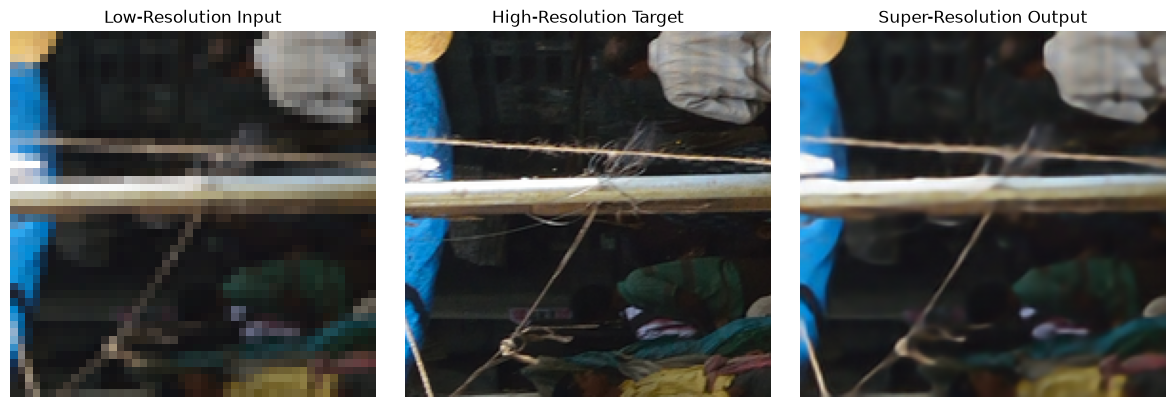

Epoch [94/200] Train Loss: 0.025920477 Val Loss: 0.024675697 Best: 0.024675697
Training time: 15204.36s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [95/200] Train Loss: 0.025420842 Val Loss: 0.024740596 Best: 0.024675697
Training time: 15365.44s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [96/200] Train Loss: 0.026541358 Val Loss: 0.024736479 Best: 0.024675697
Training time: 15526.99s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [97/200] Train Loss: 0.026181290 Val Loss: 0.024728438 Best: 0.024675697
Training time: 15688.67s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


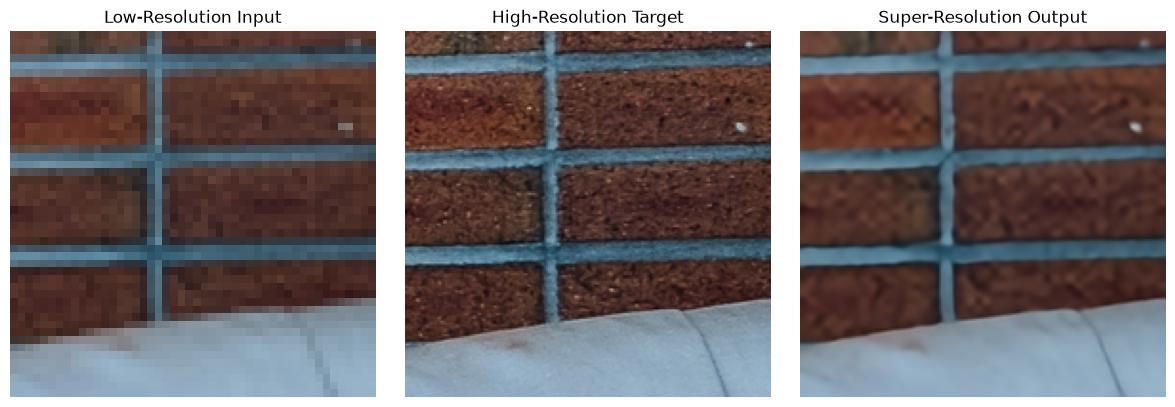

Epoch [98/200] Train Loss: 0.024921946 Val Loss: 0.024655211 Best: 0.024655211
Training time: 15850.69s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [99/200] Train Loss: 0.024917734 Val Loss: 0.024827170 Best: 0.024655211
Training time: 16012.13s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


Epoch [100/200] Train Loss: 0.024876300 Val Loss: 0.024801063 Best: 0.024655211
Training time: 16173.77s


...

100%|██████████| 200/200 [02:06<00:00,  1.57it/s]


Epoch [123/200] Train Loss: 0.025372529 Val Loss: 0.024714376 Best: 0.024655211
Training time: 19888.14s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [124/200] Train Loss: 0.025224225 Val Loss: 0.024721653 Best: 0.024655211
Training time: 20050.08s


100%|██████████| 200/200 [02:09<00:00,  1.54it/s]


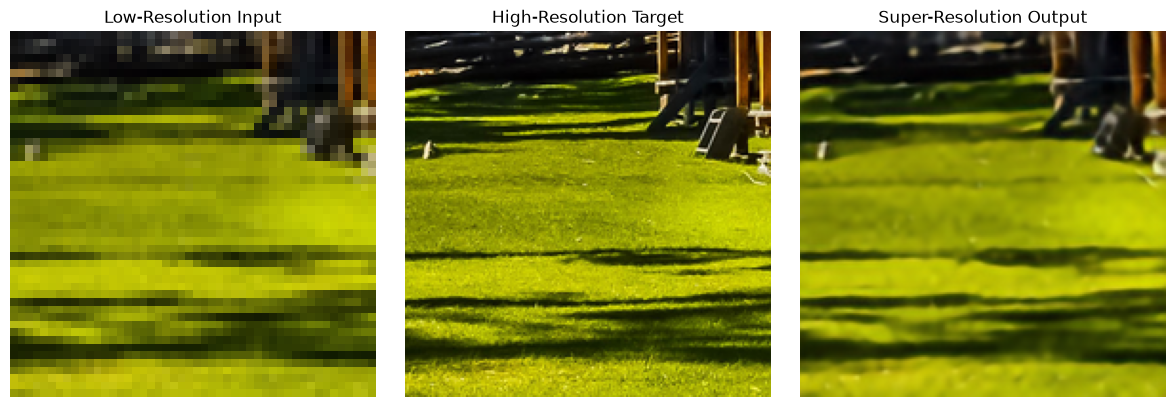

Epoch [125/200] Train Loss: 0.025017725 Val Loss: 0.024610608 Best: 0.024610608
Training time: 20214.42s


100%|██████████| 200/200 [02:09<00:00,  1.55it/s]


Epoch [126/200] Train Loss: 0.025453383 Val Loss: 0.024611175 Best: 0.024610608
Training time: 20378.82s


100%|██████████| 200/200 [02:07<00:00,  1.56it/s]


Epoch [127/200] Train Loss: 0.026270617 Val Loss: 0.024770431 Best: 0.024610608
Training time: 20541.42s


...

100%|██████████| 200/200 [02:06<00:00,  1.57it/s]


Epoch [148/200] Train Loss: 0.025294126 Val Loss: 0.024737487 Best: 0.024610608
Training time: 23937.66s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [149/200] Train Loss: 0.025560236 Val Loss: 0.024730045 Best: 0.024610608
Training time: 24099.44s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


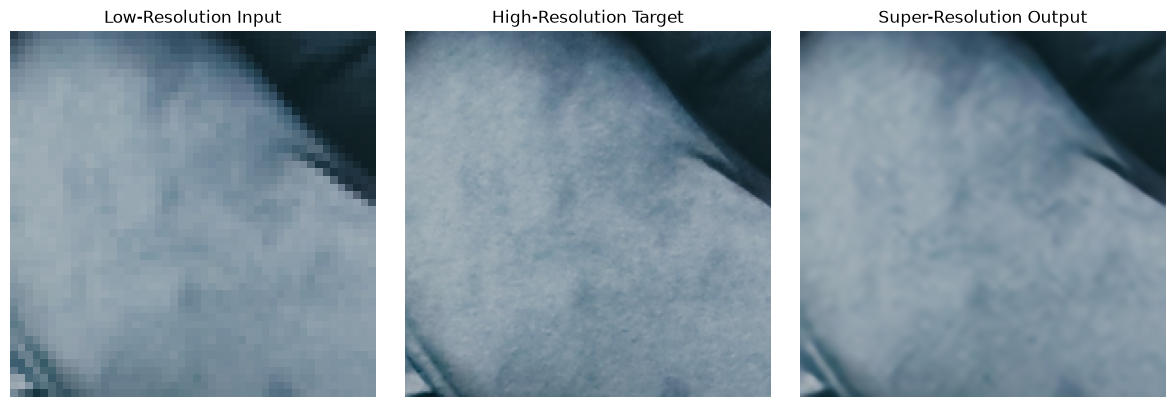

Epoch [150/200] Train Loss: 0.025421485 Val Loss: 0.024579467 Best: 0.024579467
Training time: 24261.30s


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


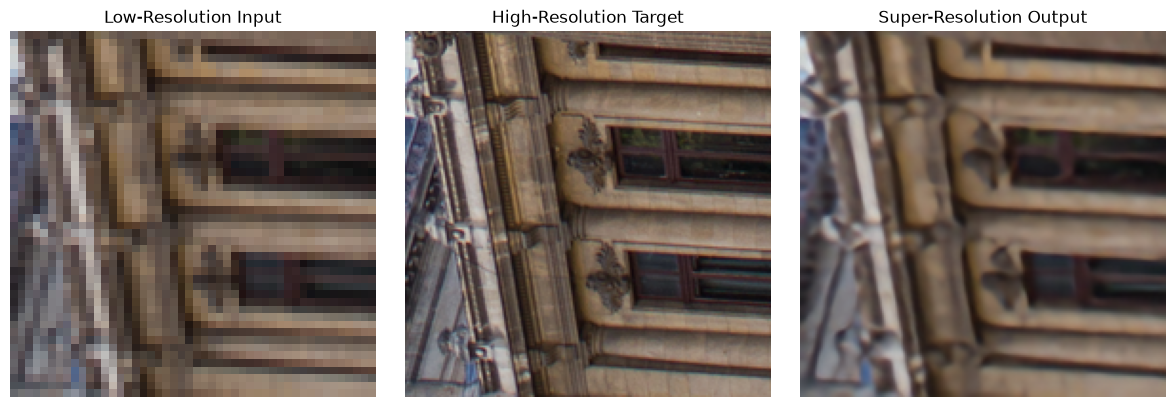

Epoch [151/200] Train Loss: 0.025744070 Val Loss: 0.024553461 Best: 0.024553461
Training time: 24423.01s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [152/200] Train Loss: 0.025046097 Val Loss: 0.024660312 Best: 0.024553461
Training time: 24584.85s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


Epoch [153/200] Train Loss: 0.025598081 Val Loss: 0.024594476 Best: 0.024553461
Training time: 24746.94s


...

Epoch [180/200] Train Loss: 0.025743505 Val Loss: 0.024563805 Best: 0.024553461
Training time: 29127.33s


100%|██████████| 200/200 [02:09<00:00,  1.55it/s]


Epoch [181/200] Train Loss: 0.024840328 Val Loss: 0.024648237 Best: 0.024553461
Training time: 29294.49s


100%|██████████| 200/200 [02:07<00:00,  1.57it/s]

Epoch [182/200] Train Loss: 0.025339661 Val Loss: 0.024593863 Best: 0.024553461
Training time: 29461.97s
Early stopping triggered.


In [6]:
import random
import time
import matplotlib.pyplot as plt
patience = MAX_PATIENCE
train_losses = []
test_losses = []
time_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for lr_images, hr_images in tqdm(train_loader):
        lr_images = lr_images.to(device)
        hr_images = hr_images.to(device)
        optimizer.zero_grad()
        with autocast:
            outputs = model(lr_images, False)
            loss = criterion(outputs, hr_images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    #scheduler.step()

    # Validation
    model.eval()
    running_test_loss = 0.0
    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
                loss = criterion(outputs, hr_images)
            running_test_loss += loss.item()
    test_loss = running_test_loss / len(test_loader)
    test_losses.append(test_loss)

    # Visualization
    if test_loss <= best_loss:
        best_loss = test_loss
        torch.save(model.state_dict(), f"weights/dlgsanet_{STEP:02d}.pth")
        with torch.inference_mode():
            random_idx = random.randrange(len(train_dataset))
            lr_image, hr_image = train_dataset[random_idx]
            lr_input = lr_image.unsqueeze(0).to(device)
            output = model(lr_input).squeeze(0).cpu()
            lr_image = lr_image.cpu()
            hr_image = hr_image.cpu()
        # [C, H, W] -> [H, W, C]
        lr_image = lr_image.permute(1, 2, 0).numpy()
        hr_image = hr_image.permute(1, 2, 0).numpy()
        output = output.permute(1, 2, 0).numpy()
        # Clamp because model output can slightly exceed [0, 1]
        lr_image = lr_image.clip(0, 1)
        hr_image = hr_image.clip(0, 1)
        output = output.clip(0, 1)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(lr_image)
        axs[0].set_title("Low-Resolution Input")
        axs[0].axis("off")

        axs[1].imshow(hr_image)
        axs[1].set_title("High-Resolution Target")
        axs[1].axis("off")

        axs[2].imshow(output)
        axs[2].set_title("Super-Resolution Output")
        axs[2].axis("off")

        plt.tight_layout()
        plt.show()

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.9f} "
        f"Val Loss: {test_loss:.9f} "
        f"Best: {best_loss:.9f}"
    )
    print(f"Training time: {time.time() - time_start:.2f}s")

    if test_loss > best_loss:
        patience -= 1
        if patience == 0:
            print("Early stopping triggered.")
            break
    else:
        patience = round(MAX_PATIENCE - (MAX_PATIENCE - MIN_PATIENCE) * (epoch + 1) / EPOCHS)
        patience = max(5, patience)

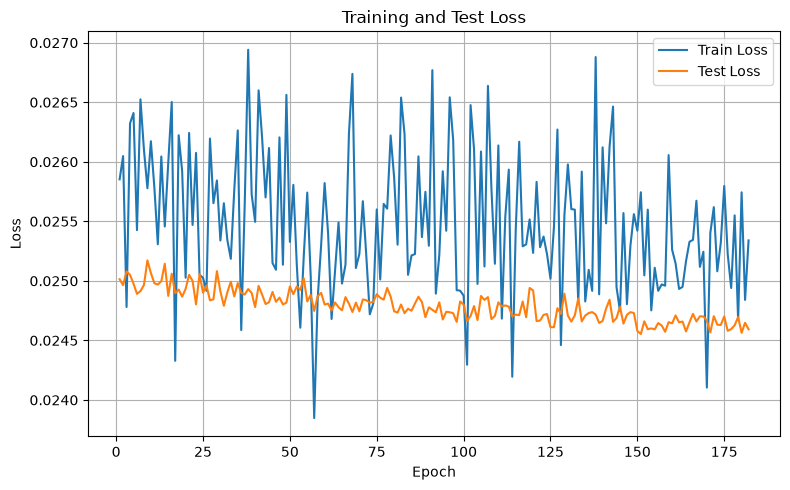

In [7]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import cv2
import numpy as np
from torchvision.transforms import v2
from skimage.metrics import structural_similarity as compare_ssim
def calculate_psnr(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf'),0  # Perfect match
    max_pixel = 1
    psnr = 10 * np.log10(max_pixel ** 2 / mse)
    return psnr,mse

def calculate_ssim(img1, img2, rgb=False):
    if rgb:
        img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    else:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    ssim, _ = compare_ssim(img1, img2, full=True, data_range=1.0,)
    return ssim

to_tensor = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

In [9]:
model.load_state_dict(torch.load(f"weights/dlgsanet_{STEP:02d}.pth", map_location=device))

def evaluate_test_loader(test_loader):
    model.eval()

    psnr_scores = []
    ssim_scores = []

    with torch.inference_mode():
        for lr_images, hr_images in tqdm(test_loader):
            lr_images = lr_images.to(device)
            hr_images = hr_images.to(device)
            with autocast:
                outputs = model(lr_images)
            outputs = outputs.clamp(0, 1).float()
            # NCHW -> NHWC
            outputs = outputs.cpu().permute(0, 2, 3, 1).numpy()
            hr_images = hr_images.cpu().permute(0, 2, 3, 1).numpy()

            for output, hr in zip(outputs, hr_images):
                psnr, _ = calculate_psnr(output, hr)
                ssim = calculate_ssim(output, hr)

                psnr_scores.append(psnr)
                ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"PSNR: min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )
    print(
        f"SSIM: min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results
results = evaluate_test_loader(final_test_loader)

100%|██████████| 100/100 [02:00<00:00,  1.21s/it]

PSNR: min=20.0601, mean=28.7339, max=43.6279
SSIM: min=0.5354, mean=0.8295, max=0.9893


In [10]:
from PIL import Image
def evaluate_bicubic(test_loader):
    psnr_scores = []
    ssim_scores = []

    for lr_images, hr_images in tqdm(test_loader):
        for lr, hr in zip(lr_images, hr_images):
            lr = lr.permute(1, 2, 0).numpy()
            hr = hr.permute(1, 2, 0).numpy()

            # LR tensor [0,1] -> PIL
            lr_pil = Image.fromarray(
                (lr * 255).clip(0, 255).astype(np.uint8)
            )

            # PIL bicubic upscale
            bicubic_pil = lr_pil.resize(
                (hr.shape[1], hr.shape[0]),
                Image.Resampling.BICUBIC,
            )

            # PIL -> [0,1] float
            bicubic = np.asarray(bicubic_pil).astype(np.float32) / 255.0

            psnr, _ = calculate_psnr(bicubic, hr)
            ssim = calculate_ssim(bicubic, hr)

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

    results = {
        "psnr": {
            "min": float(np.min(psnr_scores)),
            "mean": float(np.mean(psnr_scores)),
            "max": float(np.max(psnr_scores)),
        },
        "ssim": {
            "min": float(np.min(ssim_scores)),
            "mean": float(np.mean(ssim_scores)),
            "max": float(np.max(ssim_scores)),
        },
    }

    print(
        f"Bicubic PSNR: "
        f"min={results['psnr']['min']:.4f}, "
        f"mean={results['psnr']['mean']:.4f}, "
        f"max={results['psnr']['max']:.4f}"
    )

    print(
        f"Bicubic SSIM: "
        f"min={results['ssim']['min']:.4f}, "
        f"mean={results['ssim']['mean']:.4f}, "
        f"max={results['ssim']['max']:.4f}"
    )

    return results

bicubic_results = evaluate_bicubic(final_test_loader)

100%|██████████| 100/100 [00:43<00:00,  2.30it/s]

Bicubic PSNR: min=16.4720, mean=26.6952, max=37.9498
Bicubic SSIM: min=0.4498, mean=0.7679, max=0.9810


In [11]:
import json

log = {
    "model_type": "DLGSANet",
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "psnr": results["psnr"]["mean"],
    "ssim": results["ssim"]["mean"],
}

with open("results.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(log) + "\n")